torch.Size([1, 1, 160, 224, 160])


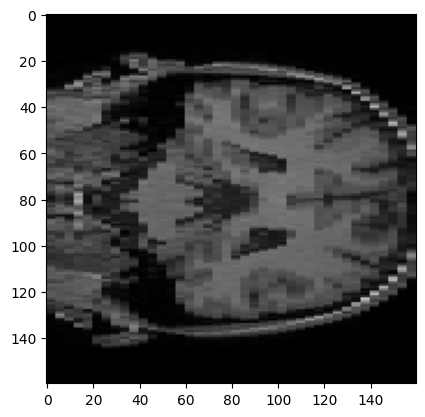

In [ ]:
import torch
from monai.data import NibabelReader
from monai.transforms import apply_transform
from monai.transforms import (
    EnsureChannelFirstd,
    Compose,
    LoadImaged,
    Orientationd,
    ScaleIntensityd,
    SpatialCropd,
    SpatialPadd,
    ToTensord,
)
from typing import Any, Tuple
import torch.nn.functional as F

from pathlib import Path

import matplotlib.pyplot as plt

def get_preprocessing(device: torch.device) -> Compose:
    return Compose(
        [
            LoadImaged(keys=["image"], reader=NibabelReader()),
            EnsureChannelFirstd(keys=["image"]),
            Orientationd(keys=["image"], axcodes="LAS"),
            ScaleIntensityd(keys=["image"], minv=0.0, maxv=1.0),
            SpatialCropd(
                keys=["image"],
                roi_start=[40-40, 12, 80],
                roi_end=[200-40, 236, 240],
            ),
            SpatialPadd(
                keys=["image"],
                spatial_size=[160, 224, 160],
            ),
            ToTensord(keys=["image"], device=device),
        ]
    )

def transform_img(
    img_path: Path,
    device: torch.device,
) -> Any:
    data = {"image": img_path}
    data = apply_transform(get_preprocessing(device), data)
    return data["image"]


def downsample_depth(input_tensor, downsample_rate):
    B, C, H, W, D = input_tensor.shape

    sampled_indices = torch.arange(0, D, downsample_rate).to(input_tensor.device)

    downsampled_tensor = input_tensor[:, :, :, :, sampled_indices]
    downsampled_tensor = downsampled_tensor.squeeze(0).squeeze(0)

    target_depth = D


    upsampled_tensor = F.interpolate(downsampled_tensor, size=(target_depth), mode='linear', align_corners=False)
    
    return upsampled_tensor.unsqueeze(0).unsqueeze(0)

def downsample_and_repeat(input_tensor, downsample_rate):
    B, C, H, W, D = input_tensor.shape

    sampled_indices = torch.arange(0, D, downsample_rate).to(input_tensor.device)

    downsampled_tensor = input_tensor[:, :, :, :, sampled_indices]  # (B, C, H, W, D//downsample_rate)


    repeat_count = downsample_rate

    repeated_tensor = downsampled_tensor.repeat_interleave(repeat_count, dim=-1)

    repeated_tensor = repeated_tensor[:, :, :, :, :D]

    return repeated_tensor


file_path = "./data_inverseSR/inputs/IXI026-Guys-0696-T1.nii.gz" 

img = transform_img(Path(file_path), torch.device("cuda"))
img = img.unsqueeze(0)
print(img.shape)
restored_img = downsample_and_repeat(img, 4).cpu()

plt.imshow(restored_img[0,0,:,100,:], cmap='gray', vmax=1, vmin=0)

In [ ]:
PARENT_DIR = "./data_inverseSR/inputs"
file_paths = [f for f in Path(PARENT_DIR).rglob("*.nii.gz")]

In [21]:
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

data = torch.zeros(len(file_paths), 2, 160, 224, 160)  # B,C,H,W,D

# First loop to process 4x downsampled data
for file_id, file_path in tqdm(enumerate(file_paths), desc="Processing files for 4x", total=len(file_paths)):
    img = transform_img(Path(file_path), torch.device("cuda:2"))
    img = img.unsqueeze(0)
    restored_img = downsample_and_repeat(img, 4)
    data[file_id, 0] = restored_img
    data[file_id, 1] = img

# Split into train and validation sets (for 4x)
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# Save each pair individually using np.save
for pair_id in range(train_data.shape[0]):
    np.save(f"train_data_4x_{pair_id}.npy", train_data[pair_id].cpu().numpy())  # Saving to .npy

for pair_id in range(val_data.shape[0]):
    np.save(f"val_data_4x_{pair_id}.npy", val_data[pair_id].cpu().numpy())  # Saving to .npy

# Second loop to process 8x downsampled data
for file_id, file_path in tqdm(enumerate(file_paths), desc="Processing files for 8x", total=len(file_paths)):
    img = transform_img(Path(file_path), torch.device("cuda"))
    img = img.unsqueeze(0)
    restored_img = downsample_and_repeat(img, 8)
    data[file_id, 0] = restored_img
    data[file_id, 1] = img

# Split into train and validation sets (for 8x)
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# Save each pair individually using np.save
for pair_id in range(train_data.shape[0]):
    np.save(f"train_data_8x_{pair_id}.npy", train_data[pair_id].cpu().numpy())  # Saving to .npy

for pair_id in range(val_data.shape[0]):
    np.save(f"val_data_8x_{pair_id}.npy", val_data[pair_id].cpu().numpy())  # Saving to .npy


Processing files for 8x: 100%|██████████| 581/581 [01:34<00:00,  6.16it/s]
